# Setup and Data Loading

In [1]:
%pip install matplotlib

import math 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statistics import mean, median, stdev

You should consider upgrading via the '/Users/christophstein/Documents/jku/qcs-rl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
plt.rcParams["figure.dpi"] = 120

In [3]:
LOG_DIR = "logs"

In [4]:
test_df_raw = pd.read_csv(f"{LOG_DIR}/eval.monitor.csv", skiprows=1)
test_df_raw.head()

,r,l,t
0,-90.01,10,28.952910
1,1000.00,1,28.953255
2,-180.01,10,28.955581
3,-180.01,10,28.957872
4,-180.01,10,28.960152


In [5]:
# All of the following must be same as in training code.
EPISODE_CUTOFF = 10 
N_EVAL_EPISODES=1_000
EVAL_FREQUENCY=50_000

# Data Preparation

In [6]:
def compute_success_rate(data: pd.DataFrame) -> float:
    return len(data[data < EPISODE_CUTOFF]) / len(data)

In [7]:
print(test_df_raw.columns)

assert len(test_df_raw) % N_EVAL_EPISODES == 0

per_eval_data = []
for i in range(int(len(test_df_raw) / N_EVAL_EPISODES)):

    start_step = i * N_EVAL_EPISODES
    end_step = start_step + N_EVAL_EPISODES

    current_eval_df = test_df_raw[start_step: end_step + 1]

    r_mean = current_eval_df["r"].mean()
    r_stdev = current_eval_df["r"].std()

    # only compute length scores for successful rounds
    current_eval_succ_df = current_eval_df[current_eval_df["l"] < EPISODE_CUTOFF]
    l_mean = current_eval_succ_df["l"].mean()
    l_stdev = current_eval_succ_df["l"].std()

    succ_pct = len(current_eval_succ_df) / len(current_eval_df)

    train_step = (i + 1) * EVAL_FREQUENCY
    train_step = f"{round(train_step / 10**6, 2)} Mio."

    per_eval_data.append({
        "steps": train_step,
        "r_mean": r_mean,
        "r_stdev": r_stdev,
        "r_lower_bound": r_mean - r_stdev,
        "r_upper_bound": r_mean + r_stdev,
        "l_mean": l_mean,
        "l_stdev": l_stdev,
        "l_lower_bound": l_mean - l_stdev,
        "l_upper_bound": l_mean + l_stdev,
        "succ_pct": succ_pct,
    })


test_df = pd.DataFrame(per_eval_data)

test_df.head()

Index(['r', 'l', 't'], dtype='object')


,steps,r_mean,r_stdev,r_lower_bound,r_upper_bound,l_mean,l_stdev,l_lower_bound,l_upper_bound,succ_pct
0,0.05 Mio.,60.743966,462.633596,-401.889630,523.377562,1.072165,0.278688,0.793477,1.350853,0.193806
1,0.1 Mio.,248.154515,515.338225,-267.183710,763.492741,1.047022,0.212018,0.835004,1.259040,0.318681
2,0.15 Mio.,290.703387,516.309087,-225.605701,807.012474,1.661850,1.113080,0.548770,2.774929,0.345654
3,0.2 Mio.,448.954545,524.491347,-75.536802,973.445893,2.910638,1.901770,1.008868,4.812409,0.469530
4,0.25 Mio.,556.099780,511.371136,44.728644,1067.470916,3.259325,2.118441,1.140884,5.377766,0.562438


# Data Analysis

## Plot Reward over Steps 

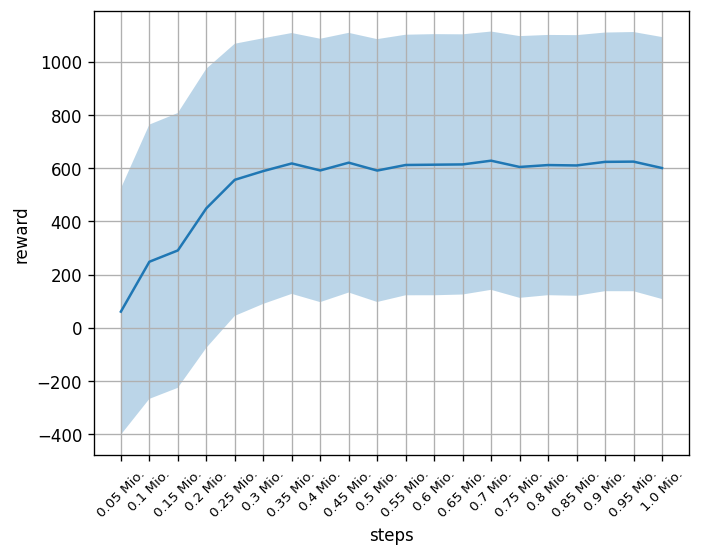

In [8]:
ax = plt.subplot()

ax.plot(test_df["steps"], test_df["r_mean"])
ax.fill_between(
    test_df["steps"], test_df["r_lower_bound"], test_df["r_upper_bound"], alpha=0.3
)


ax.set_xlabel("steps")
ax.set_ylabel("reward")

plt.grid()
plt.xticks(fontsize=8, rotation=45)
plt.show()

## Plot Circuit Length over Steps

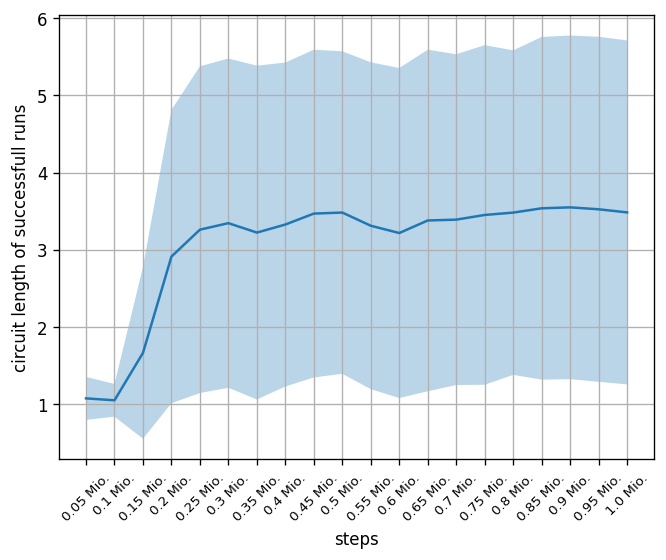

In [9]:
ax = plt.subplot()



ax = plt.subplot()

ax.plot(test_df["steps"], test_df["l_mean"])
ax.fill_between(
    test_df["steps"], test_df["l_lower_bound"], test_df["l_upper_bound"], alpha=0.3
)

ax.set_xlabel("steps")
ax.set_ylabel("circuit length of successfull runs")

plt.grid()
plt.xticks(fontsize=8, rotation=45)
plt.show()


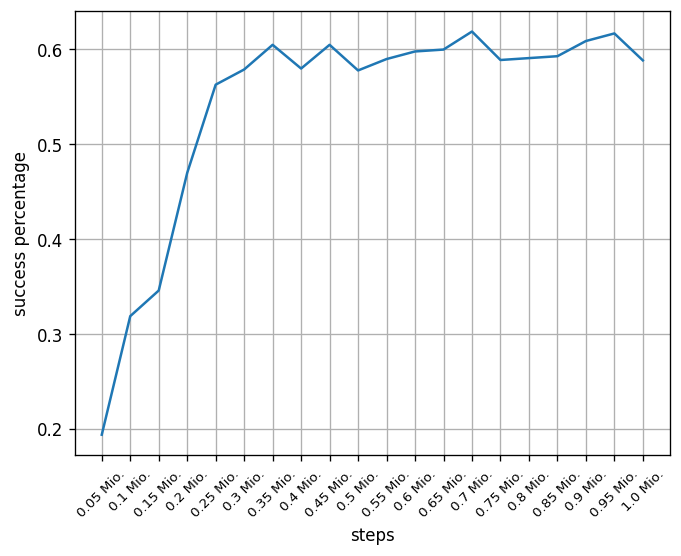

In [10]:

ax = plt.subplot()

ax.plot(test_df["steps"], test_df["succ_pct"])

ax.set_xlabel("steps")
ax.set_ylabel("success percentage")

plt.grid()
plt.xticks(fontsize=8, rotation=45)
plt.show()